## TODO:
1. rename the columns
2. group the data by the time of the day 
4. find the average consumption

In [3]:
import polars as pl
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt

/home/ahmed/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
plt.style.use('ggplot')

In [27]:
%%time
data=pl.read_csv('load_profile_data_mobile_home.csv', ignore_errors=True)
edit_column_names(data)
data

upgrade
in.state
in.geometry_building_type_recs
timestamp
models_used
units_represented
out.electricity.ceiling_fan.kwh
out.electricity.clothes_dryer.kwh
out.electricity.clothes_washer.kwh
out.electricity.cooling_fans_pumps.kwh
out.electricity.cooling.kwh
out.electricity.dishwasher.kwh
out.electricity.freezer.kwh
out.electricity.heating_fans_pumps.kwh
out.electricity.heating_hp_bkup.kwh
out.electricity.heating.kwh
out.electricity.hot_tub_heater.kwh
out.electricity.hot_tub_pump.kwh
out.electricity.hot_water.kwh
out.electricity.lighting_exterior.kwh
out.electricity.lighting_garage.kwh
out.electricity.lighting_interior.kwh
out.electricity.mech_vent.kwh
out.electricity.plug_loads.kwh
out.electricity.pool_heater.kwh
out.electricity.pool_pump.kwh
out.electricity.pv.kwh
out.electricity.range_oven.kwh
out.electricity.refrigerator.kwh
out.electricity.well_pump.kwh
out.fuel_oil.heating_hp_bkup.kwh
out.fuel_oil.heating.kwh
out.fuel_oil.hot_water.kwh
out.natural_gas.clothes_dryer.kwh
out.natural_g

upgrade,in.state,in.geometry_building_type_recs,timestamp,models_used,units_represented,out.electricity.ceiling_fan.energy_consumption.kwh,out.electricity.clothes_dryer.energy_consumption.kwh,out.electricity.clothes_washer.energy_consumption.kwh,out.electricity.cooling_fans_pumps.energy_consumption.kwh,out.electricity.cooling.energy_consumption.kwh,out.electricity.dishwasher.energy_consumption.kwh,out.electricity.freezer.energy_consumption.kwh,out.electricity.heating_fans_pumps.energy_consumption.kwh,out.electricity.heating_hp_bkup.energy_consumption.kwh,out.electricity.heating.energy_consumption.kwh,out.electricity.hot_tub_heater.energy_consumption.kwh,out.electricity.hot_tub_pump.energy_consumption.kwh,out.electricity.hot_water.energy_consumption.kwh,out.electricity.lighting_exterior.energy_consumption.kwh,out.electricity.lighting_garage.energy_consumption.kwh,out.electricity.lighting_interior.energy_consumption.kwh,out.electricity.mech_vent.energy_consumption.kwh,out.electricity.plug_loads.energy_consumption.kwh,out.electricity.pool_heater.energy_consumption.kwh,out.electricity.pool_pump.energy_consumption.kwh,out.electricity.pv.energy_consumption.kwh,out.electricity.range_oven.energy_consumption.kwh,out.electricity.refrigerator.energy_consumption.kwh,out.electricity.well_pump.energy_consumption.kwh,out.fuel_oil.heating_hp_bkup.energy_consumption.kwh,out.fuel_oil.heating.energy_consumption.kwh,out.fuel_oil.hot_water.energy_consumption.kwh,out.natural_gas.clothes_dryer.energy_consumption.kwh,out.natural_gas.fireplace.energy_consumption.kwh,out.natural_gas.grill.energy_consumption.kwh,out.natural_gas.heating_hp_bkup.energy_consumption.kwh,out.natural_gas.heating.energy_consumption.kwh,out.natural_gas.hot_tub_heater.energy_consumption.kwh,out.natural_gas.hot_water.energy_consumption.kwh,out.natural_gas.lighting.energy_consumption.kwh,out.natural_gas.pool_heater.energy_consumption.kwh,out.natural_gas.range_oven.energy_consumption.kwh,out.propane.clothes_dryer.energy_consumption.kwh,out.propane.heating_hp_bkup.energy_consumption.kwh,out.propane.heating.energy_consumption.kwh,out.propane.hot_water.energy_consumption.kwh,out.propane.range_oven.energy_consumption.kwh,out.site_energy.net.energy_consumption.kwh,out.site_energy.total.energy_consumption.kwh,out.electricity.net.energy_consumption.kwh,out.electricity.total.energy_consumption.kwh,out.fuel_oil.total.energy_consumption.kwh,out.natural_gas.total.energy_consumption.kwh,out.propane.total.energy_consumption.kwh,out.load.cooling.energy_delivered.kbtu,out.load.heating.energy_delivered.kbtu,out.load.hot_water.energy_delivered.kbtu,out.emissions.all_fuels.lrmer_95decarbby2035_15_2025start.co2e_kg,out.emissions.all_fuels.lrmer_lowrecost_15_2025start.co2e_kg,out.emissions.all_fuels.lrmer_lowrecost_25_2025start.co2e_kg,out.emissions.all_fuels.lrmer_midcase_15_2025start.co2e_kg
i64,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""AL""","""Mobile Home""","""2007-01-01 00:15:00""",1233,298547.538693,411.622722,1348.185479,66.101766,108.232563,1883.779279,0.0,688.136338,1974.82054,143.825822,89435.69004,46.247023,50.847513,12726.406029,853.027558,0.0,2881.11692,152.784669,21217.940645,0.0,0.0,0.0,566.102308,3811.626402,495.884314,0.0,31.648871,108.145471,0.0,720.402112,35.338874,0.0,9053.422211,0.0,3740.172787,57.691777,0.0,21.288478,0.0,0.0,20774.645585,1031.426783,0.0,174567.368653,174567.368653,139001.119,139001.119,139.794342,13628.600086,21806.072368,5755.454173,465780.649515,42865.179576,46108.997125,91893.951025,77160.488293,94354.210148
0,"""AL""","""Mobile Home""","""2007-01-01 00:30:00""",1233,298547.538693,401.937481,1366.829567,39.467355,76.997662,1764.892952,0.0,688.136338,2040.922306,216.222994,92380.003155,46.247023,50.847513,13820.353944,853.027558,0.0,2785.233039,152.784669,2

In [24]:
def edit_column_names(df):
    df=df.rename(lambda col: col.replace('.energy_consumption',''))
    for column in df.columns:
        print(column)

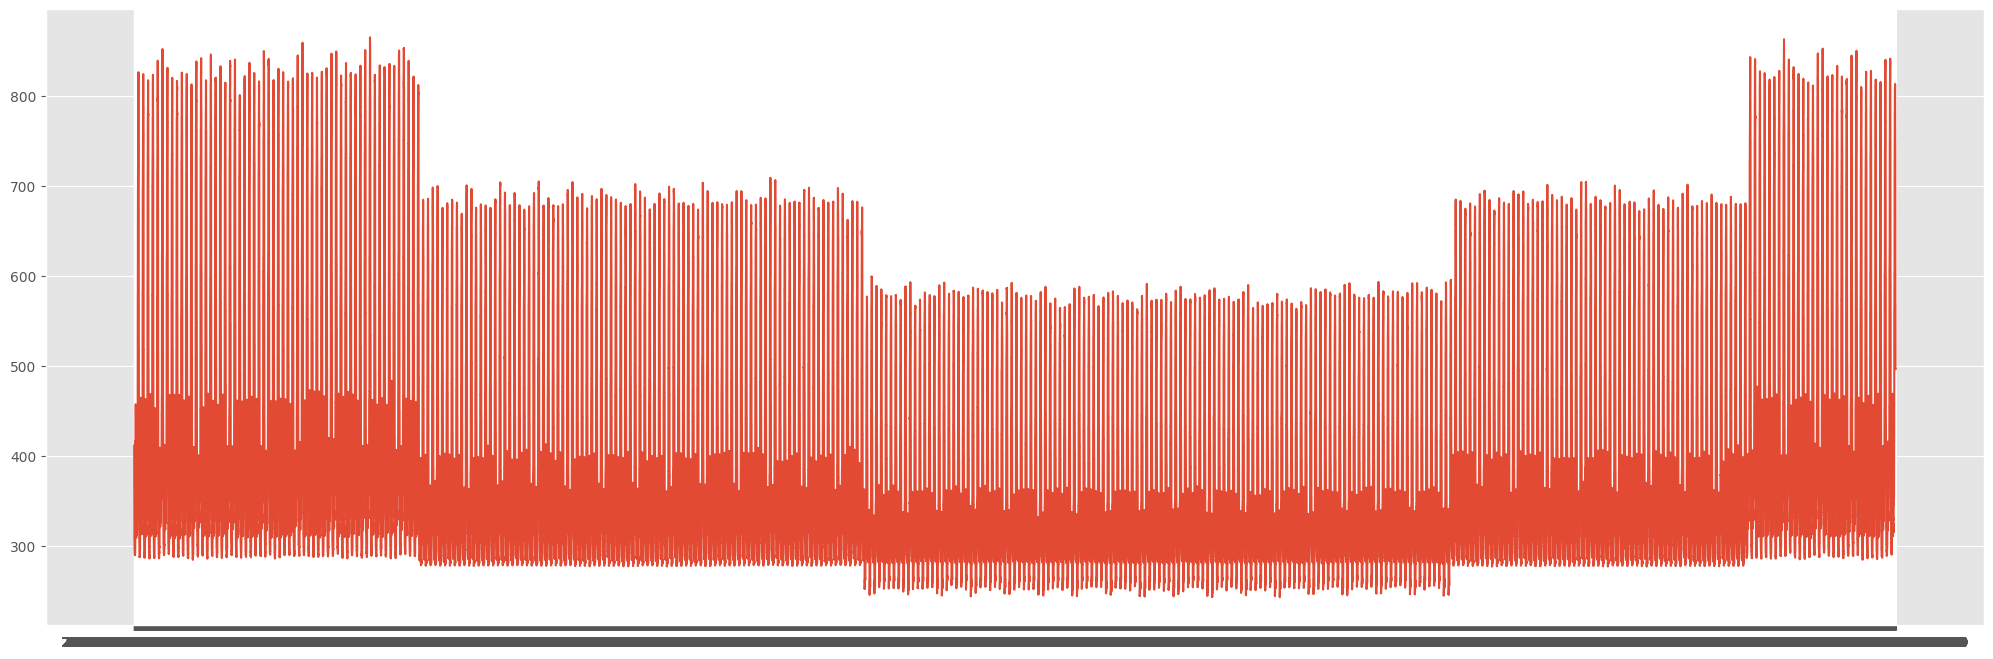

In [29]:
fig, ax=plt.subplots(figsize=(25,8))
ax.step(data['timestamp'], data['out.electricity.ceiling_fan.energy_consumption.kwh'])
plt.show()

In [8]:
# data.describe()